In [65]:
import os

project_folder = "customer-churn-project"
os.makedirs(project_folder, exist_ok=True)

print("Customer Churn Project folder created!")

Customer Churn Project folder created!


In [66]:
import os
os.makedirs("customer-churn-project/data", exist_ok=True)
os.makedirs("customer-churn-project/notebooks", exist_ok=True)
os.makedirs("customer-churn-project/src", exist_ok=True)
os.makedirs("customer-churn-project/models", exist_ok=True)
os.makedirs("customer-churn-project/app", exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


In [79]:
readme = """# Customer Churn Prediction

## Project Overview

This project predicts whether a customer is likely to churn using Machine Learning.

## Objective

To identify customers who may leave the company and help the business take early action.

## Technologies Used

* Python
* Pandas
* NumPy
* Scikit-learn
* Streamlit
* Joblib

## Machine Learning Models

* Logistic Regression
* Decision Tree Classifier

## Project Steps

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Data Preprocessing
5. Train-Test Split
6. Model Training
7. Model Evaluation
8. Hyperparameter Tuning
9. Model Saving
10. Streamlit Deployment

## Model Evaluation

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

## Streamlit App

The trained model is used in a Streamlit application to predict customer churn.

## How to Run

Install the required libraries:

```bash
pip install -r requirements.txt
```

Run the Streamlit app:

```bash
streamlit run app/app.py
```

## Project Structure

```text
customer-churn-project/
│
├── data/
├── notebooks/
├── src/
├── models/
├── app/
│   └── app.py
├── README.md
├── requirements.txt
└── .gitignore
```

## Conclusion

This project demonstrates an end-to-end Machine Learning workflow for Customer Churn Prediction.

"""

with open("customer-churn-project/README.md", "w") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [4]:
import os

os.makedirs("customer-churn-project/data/raw", exist_ok=True)
os.makedirs("customer-churn-project/data/processed", exist_ok=True)

print("Data folders created successfully!")

Data folders created successfully!


In [5]:
from google.colab import files
uploaded=files.upload()

Saving WA_FnUseC_TelcoCustomerChurn.csv to WA_FnUseC_TelcoCustomerChurn.csv


**LOADING THE DATASET**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("customer-churn-project/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
import pandas as pd
df=pd.read_csv("customer-churn-project/TelcoCustomerChurn.csv")
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.columns)
print(df.dtypes)
print(df["TotalCharges"]==pd.to_numeric(df["TotalCharges"], errors='coerce').fillna(0))
df=df.drop(columns=["customerID"])
df.to_csv("customer-churn-project/data/processed/clean_TelcoCustomerChurn.csv",index=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
te

**Exploratory** **Data** **Analysis**

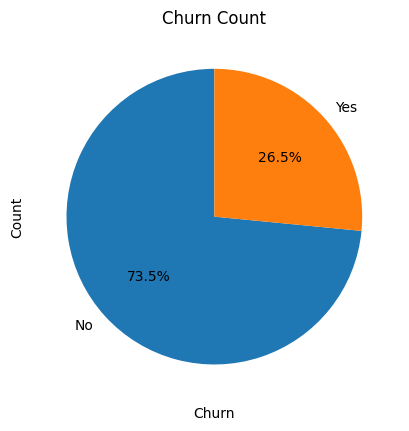

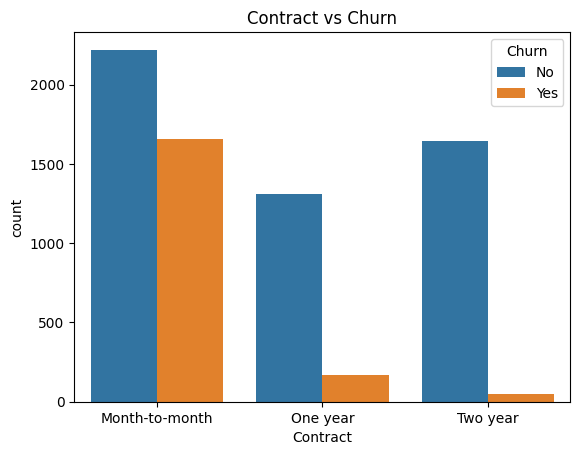

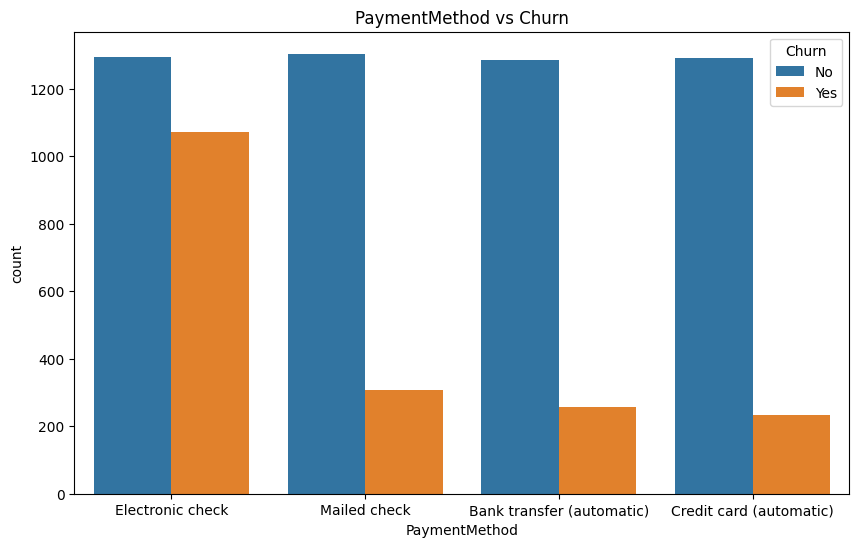

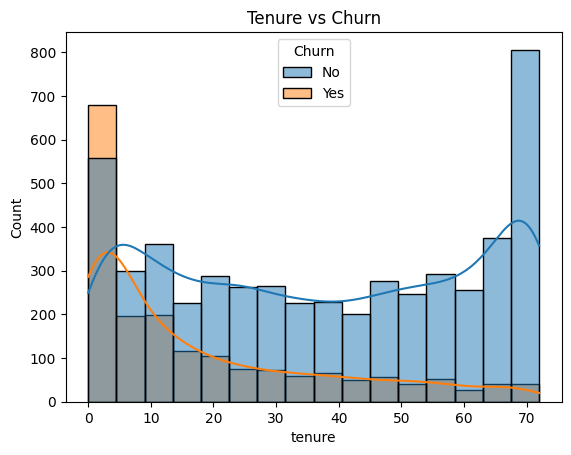

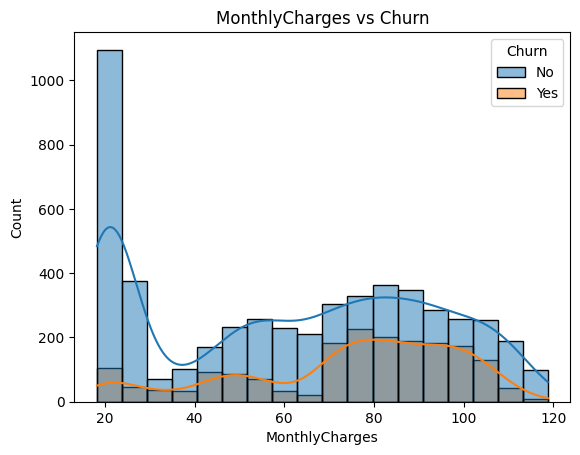

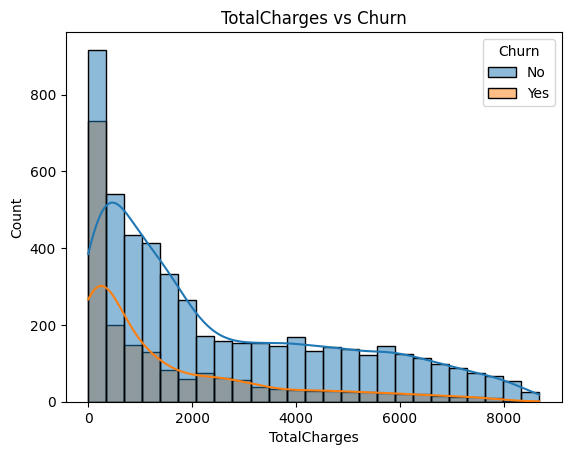

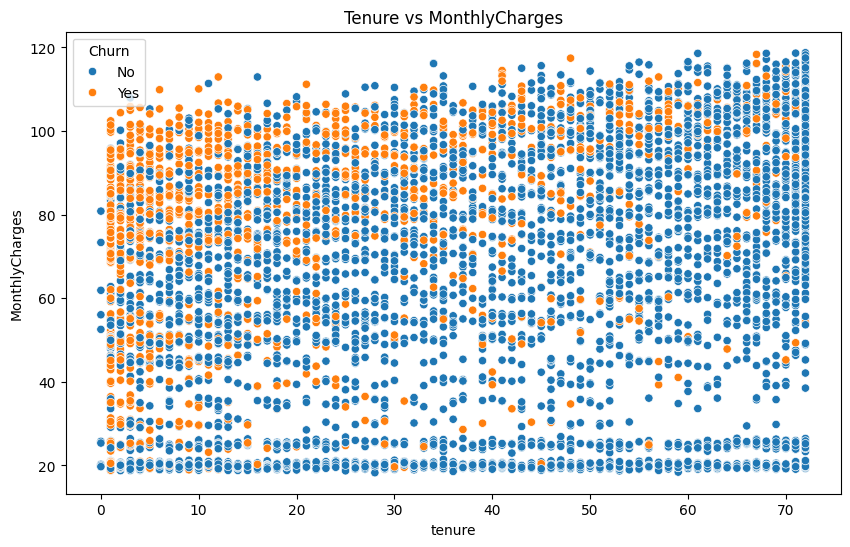

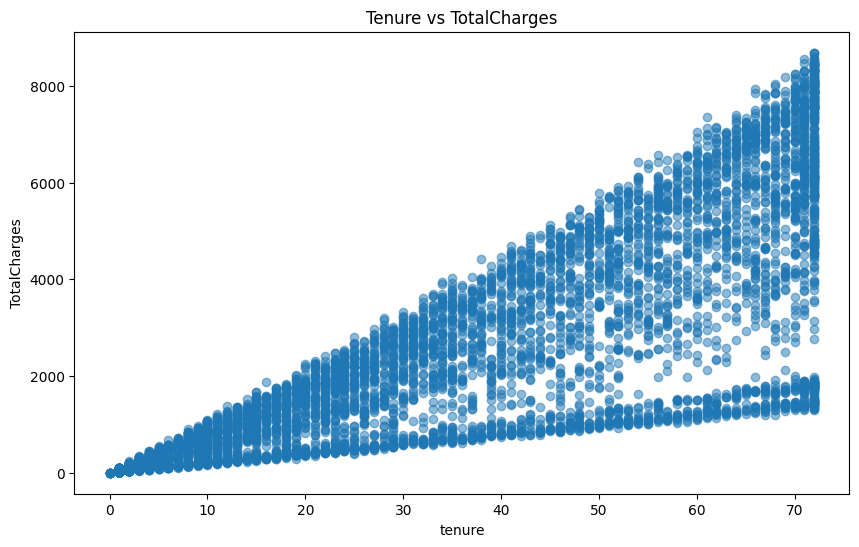

<Figure size 1000x1000 with 0 Axes>

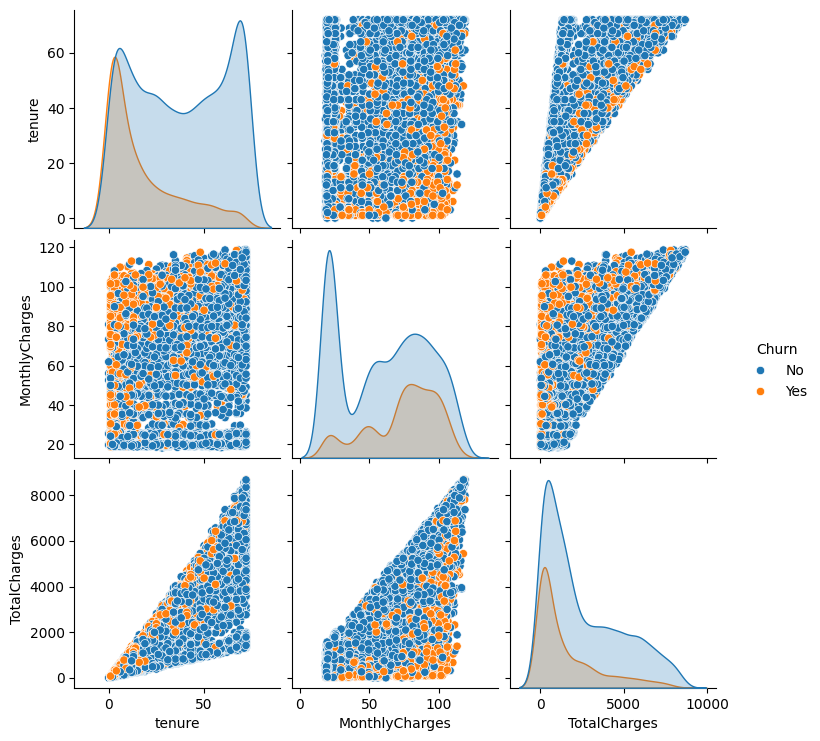

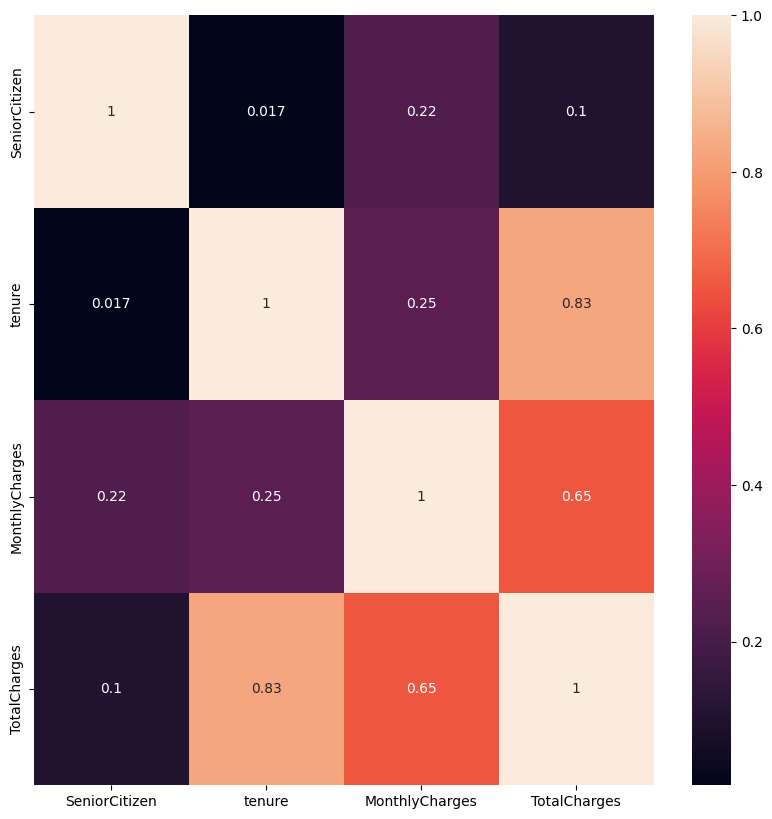

In [29]:
df=pd.read_csv("customer-churn-project/data/processed/clean_TelcoCustomerChurn.csv")
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure TotalCharges is numeric for plotting
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce').fillna(0)

# 1. Churn Count
df["Churn"].value_counts().plot(kind="pie",autopct="%1.1f%%", startangle=90)
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# 2. Contract vs Churn
sns.countplot(data=df,x="Contract",hue="Churn")
plt.title("Contract vs Churn")
plt.show()

# 3. PaymentMethod vs Churn
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="PaymentMethod",hue="Churn")
plt.title("PaymentMethod vs Churn")
plt.show()

# 4. Tenure vs Churn
sns.histplot(data=df,x="tenure",hue="Churn",kde=True)
plt.title("Tenure vs Churn")
plt.show()

# 5. MonthlyCharges vs Churn
sns.histplot(data=df,x="MonthlyCharges",hue="Churn",kde=True)
plt.title("MonthlyCharges vs Churn")
plt.show()

# 6. TotalCharges vs Churn (Now works because TotalCharges is numeric)
sns.histplot(data=df,x="TotalCharges",hue="Churn",kde=True)
plt.title("TotalCharges vs Churn")
plt.show()

# 7. Tenure vs MonthlyCharges (Added missing y parameter)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="tenure",y="MonthlyCharges",hue="Churn")
plt.title("Tenure vs MonthlyCharges")
plt.show()

# 8. Tenure vs TotalCharges (Fixed plt.plot to use dataframe columns)
plt.figure(figsize=(10,6))
plt.plot(df["tenure"], df["TotalCharges"], 'o', alpha=0.5)
plt.title("Tenure vs TotalCharges")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.show()

# 9. Pairplot
plt.figure(figsize=(10,10))
sns.pairplot(data=df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]],hue="Churn")
plt.show()

# 10. Heatmap
corr_df=df.select_dtypes(include="number").corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_df,annot=True)
plt.show()

**MACHINE LEARNING**

In [68]:
df=pd.read_csv("customer-churn-project/data/processed/clean_TelcoCustomerChurn.csv")

# Convert TotalCharges safely to numeric, coercing spaces to NaN and filling them with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce').fillna(0)

#feature and traget seperate
X=df.drop("Churn",axis=1)
y=df["Churn"].map({"Yes":1,"No":0})

#train and testing data split in process
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

#identify the features dtypes and seperate numbers,objects
numerical_features=X.select_dtypes(include=["int64","float64"]).columns
categorical_features=X.select_dtypes(include="object").columns
print(numerical_features)
print(categorical_features)

#build for features in Columntransformer(numreical and categorical,create preprocessing)
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
scaler=StandardScaler()
encoder=OneHotEncoder(handle_unknown="ignore",drop="first")
preprocessor=ColumnTransformer(transformers=[
    ("num",scaler,numerical_features),
    ("cat",encoder,categorical_features)
])

#train for ml model(classification algorithm)
#create train for pipeline(applies diff preprocessor and ml model)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
log_pipeline=Pipeline(steps=[("proprecessor",preprocessor),("model",LogisticRegression(max_iter=1000))])
log_pipeline.fit(X_train,y_train)
log_prediction=log_pipeline.predict(X_test)
print(log_prediction)
print()

tree_pipeline=Pipeline(steps=[("preprocessor",preprocessor),("model",DecisionTreeClassifier(max_depth=4,random_state=42))])
tree_pipeline.fit(X_train,y_train)
tree_prediction=tree_pipeline.predict(X_test)
print(tree_prediction)
print()

#classification model evaulation and metrics train
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.model_selection import cross_val_score
log_accuracy=accuracy_score(y_test,log_prediction)
tree_accuracy=accuracy_score(y_test,tree_prediction)
log_cm=confusion_matrix(y_test,log_prediction)
tree_cm=confusion_matrix(y_test,tree_prediction)
log_cr=classification_report(y_test,log_prediction)
tree_cr=classification_report(y_test,tree_prediction)
print("log:",log_accuracy)
print("tree:",tree_accuracy)
print("log_cm:",log_cm)
print("tree_cm:",tree_cm)
print("log_cr:",log_cr)
print("tree_cr:",tree_cr)

#train and test performance (gap for both classifications)
log_train_pred=log_pipeline.predict(X_train)
tree_train_pred=tree_pipeline.predict(X_train)
log_test_pred=log_pipeline.predict(X_test)
tree_test_pred=tree_pipeline.predict(X_test)
print(accuracy_score(y_train,log_train_pred))
print(accuracy_score(y_train,tree_train_pred))
print(accuracy_score(y_test,log_test_pred))
print(accuracy_score(y_test,tree_test_pred))

#crossvalidation and hyperparmeter best tunning
from sklearn.model_selection import cross_val_score
log_cv_scores=cross_val_score(log_pipeline,X,y,cv=5,scoring="f1")
print("logcvscore:",log_cv_scores)
print(log_cv_scores.mean())
print(log_cv_scores.std())

from sklearn.model_selection import GridSearchCV
param_grid={
    "model__max_depth":[2,3,4,5,6,8],
    "model__min_samples_split":[2,3,4,5,6,8,10],
    "model__min_samples_leaf":[1,2,5,6,7,8]
}
grid_search=GridSearchCV(
    tree_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1)
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)
#best tunned
best_tree = grid_search.best_estimator_
best_tree_train_pred = best_tree.predict(X_train)
best_tree_test_pred = best_tree.predict(X_test)
best_tree_train_accuracy = accuracy_score(y_train, best_tree_train_pred)
best_tree_test_accuracy = accuracy_score(y_test, best_tree_test_pred)

print("Original Decision Tree")
print("Train Accuracy:", accuracy_score(y_train, tree_train_pred))
print("Test Accuracy :", accuracy_score(y_test, tree_test_pred))

print("\nTuned Decision Tree")
print("Train Accuracy:", best_tree_train_accuracy)
print("Test Accuracy :", best_tree_test_accuracy)
#save to dataset
df.to_csv("customer-churn-project/src/preprocessor_TelcoCustomerChurn.csv",index=False)
#
new_data=pd.DataFrame({
    "gender":["Female"],
    "SeniorCitizen":[1],
    "Partner":["Yes"],
    "Dependents":["No"],
    "tenure":[35],
    "PhoneService":["Yes"],
    "MultipleLines":["No"],
    "InternetService":["Fiber optic"],
    "OnlineSecurity":["Yes"],
    "OnlineBackup":["No"],
    "DeviceProtection":["No"],
    "TechSupport":["No"],
    "StreamingTV":["NO"],
    "StreamingMovies":["No"],
    "Contract":["Month-to-month"],
    "PaperlessBilling":["Yes"],
    "PaymentMethod":["Electronic check"],
    "MonthlyCharges":[100],
    "TotalCharges":[3000]
})
# Fixed: use best model to predict
prediction=best_tree.predict(new_data)
print("Prediction:", prediction)


#Save the tuned model
import joblib

best_tree = grid_search.best_estimator_

joblib.dump(
    best_tree,
    "customer-churn-project/models/customer_churn_model.pkl"
)

print("Model saved successfully!")

(5634, 19)
(1409, 19)
(5634,)
(1409,)
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
[1 0 0 ... 0 0 0]

[1 0 0 ... 0 0 1]

log: 0.8211497515968772
tree: 0.8026969481902059
log_cm: [[934 102]
 [150 223]]
tree_cm: [[934 102]
 [176 197]]
log_cr:               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

tree_cr:               precision    recall  f1-score   support

           0       0.84      0.90     

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [72]:
# Install streamlit in the environment
!pip install -q streamlit

import os
import shutil

os.makedirs("customer-churn-project/app", exist_ok=True)

# If app.py is accidentally a directory, remove it so we can create it as a file
app_path = "customer-churn-project/app/app.py"
if os.path.exists(app_path):
    if os.path.isdir(app_path):
        shutil.rmtree(app_path)
    else:
        os.remove(app_path)

# Write the Streamlit application code to app.py
with open(app_path, "w") as f:
    f.write('''import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("customer-churn-project/models/customer_churn_model.pkl")

st.title("Customer Churn Prediction")

st.write("Enter Customer Details")

tenure = st.number_input("Tenure", min_value=0)
monthly_charges = st.number_input("Monthly Charges", min_value=0.0)
total_charges = st.number_input("Total Charges", min_value=0.0)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

payment_method = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

if st.button("Predict Churn"):

    data = pd.DataFrame({
        "tenure": [tenure],
        "MonthlyCharges": [monthly_charges],
        "TotalCharges": [total_charges],
        "Contract": [contract],
        "InternetService": [internet_service],
        "PaymentMethod": [payment_method]
    })

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.error("Customer is likely to Churn")
    else:
        st.success("Customer is not likely to Churn")
''')

print("Streamlit app saved successfully to customer-churn-project/app/app.py!")

Streamlit app saved successfully to customer-churn-project/app/app.py!


In [75]:
import os
import shutil

req_path = "customer-churn-project/requirements.txt"

# If requirements.txt is accidentally a directory, delete it first
if os.path.exists(req_path):
    if os.path.isdir(req_path):
        shutil.rmtree(req_path)
    else:
        os.remove(req_path)

# Now write the package names into requirements.txt file
with open(req_path, "w") as f:
    f.write("""pandas
numpy
scikit-learn
joblib
streamlit
matplotlib
seaborn
""")

# Run pip install with the exclamation mark (!) to execute it in the system shell
!pip install -r customer-churn-project/requirements.txt

In [78]:
import os
import shutil

gitignore_path = "customer-churn-project/.gitignore"
gitignore_content = """__pycache__/
*.pyc
venv/
.venv/
.ipynb_checkpoints/
"""

# If .gitignore is accidentally a directory, delete it first
if os.path.exists(gitignore_path):
    if os.path.isdir(gitignore_path):
        shutil.rmtree(gitignore_path)
    else:
        os.remove(gitignore_path)

# Write the ignore rules to the .gitignore file
with open(gitignore_path, "w") as f:
    f.write(gitignore_content)

print(".gitignore file successfully created!")

.gitignore file successfully created!
